# 10 — Financial Hypothesis Test: Replacing Physical PBX / 財務假設檢定：汰換實體 PBX

**EN.** This notebook applies **null-hypothesis significance testing** (per the framework at
[yongxi-stat.com/hypothesis-stat](https://www.yongxi-stat.com/hypothesis-stat/)) to a single
business question:

> *Is replacing a physical (on-premise / TDM) PBX with a modern alternative (cloud / IP-PBX)
> financially reasonable — in **Taiwan** and **worldwide**, over **3-, 5- and 10-year** horizons?*

We answer it with an explicit **Total-Cost-of-Ownership (TCO)** model built from *real* market
prices (sourced below), not ordinal guesses. Cost uncertainty is propagated by **Monte-Carlo
sampling** over the published price *ranges*, which gives each market/horizon a proper sample on
which to run a **one-sided t-test**.

**繁中.** 本筆記本採用**虛無假設顯著性檢定**（依
[yongxi-stat.com/hypothesis-stat](https://www.yongxi-stat.com/hypothesis-stat/) 的框架），
回答單一商業問題：

> *將實體（地端 / TDM）PBX 汰換為現代替代方案（雲端 / IP-PBX），在**台灣**與**全球**、
> **3 年、5 年、10 年**期間內，是否具財務合理性？*

我們以明確的**總持有成本（TCO）**模型作答，所用價格為下方標註之*真實*市場行情，而非
順序性的主觀猜測。成本不確定性以**蒙地卡羅抽樣**在公開價格*區間*上傳播，使每個
市場／期間皆有適當樣本可進行**單尾 t 檢定**。

---

### Consistency with other notebooks / 與其他筆記本的一致性
**EN.** No logic conflict with notebooks 01–09. This notebook **reuses** the decline trajectory in
`data/processed/longhorizon_projection.csv` and the **same decline-based "market death" definition
adopted in notebook 08** (penetration falling toward each market's historical floor). That decline
is the *only* driver of the migration/stranding-risk term — we do **not** introduce a competing
death metric. We add a new, purely financial layer on top of the existing adoption story.

**繁中.** 與筆記本 01–09 無邏輯衝突。本筆記本**重用** `longhorizon_projection.csv` 的衰退軌跡，
並沿用**筆記本 08 所採之「以衰退為基礎的市場消亡定義」**（滲透率朝各市場歷史低點下滑）。
該衰退是遷移／擱淺風險項的*唯一*來源——我們**不**引入相互矛盾的消亡指標，
僅在既有採用敘事之上，疊加一層全新的純財務分析。

## 1. Hypothesis design / 假設設計

**EN.** For each market group (Taiwan; Worldwide) and horizon (3 / 5 / 10 years) we test, per seat:

- **H₀ (null):** replacing is **not** financially reasonable — mean NPV(TCO_physical − TCO_alternative) **≤ 0**.
- **H₁ (alternative):** replacing **is** financially reasonable — mean Δ **> 0** (the kept physical PBX is *more* expensive).
- **Test:** one-sample, **one-sided t-test** on the Monte-Carlo sample of per-seat NPV differences.
- **Decision rule:** reject H₀ at **α = 0.05**. We also report **Cohen's d** (effect size) and the **95% CI**.

**繁中.** 對每個市場群（台灣；全球）與期間（3 / 5 / 10 年），以每席位為單位檢定：

- **H₀（虛無）：** 汰換**不**具財務合理性——NPV(TCO_實體 − TCO_替代) 的平均值 **≤ 0**。
- **H₁（對立）：** 汰換**具**財務合理性——平均 Δ **> 0**（續用實體 PBX *較*昂貴）。
- **檢定方法：** 對每席位 NPV 差額的蒙地卡羅樣本，進行單樣本**單尾 t 檢定**。
- **判定準則：** 在 **α = 0.05** 下拒絕 H₀。另報告 **Cohen's d**（效果量）與 **95% 信賴區間**。

## 2. Real cost anchors & the discount rate / 真實成本錨點與折現率

> **⚠️ DISCOUNT RATE — 折現率 = 3% (per user request) ⚠️**
>
> **EN.** Every multi-year cost below is discounted to present value at a **3% annual real discount
> rate**. This is the single most important time-value assumption in the model: a **higher** rate
> would shrink the future subscription stream and *favour keeping* the physical box, while a
> **lower** rate would *favour replacement* even more strongly. 3% is a conservative real
> (inflation-adjusted) cost-of-capital appropriate for a low-risk infrastructure decision. A
> sensitivity sweep over 0%–8% is included in §6 so the conclusion does **not** hinge on this number.
>
> **繁中.** 下方所有跨年度成本，皆以 **3% 年實質折現率**折現為現值。這是模型中最關鍵的
> 時間價值假設：折現率**愈高**，未來訂閱費用流的現值愈小，*愈有利於續用*實體設備；
> 折現率**愈低**，則*愈有利於汰換*。3% 為適用於低風險基礎設施決策的保守實質
> （經通膨調整）資金成本。§6 提供 0%–8% 的敏感度分析，確保結論**不**取決於此單一數字。

**Sourced price ranges (USD, per seat) — used as Monte-Carlo bounds / 來源價格區間（美元，每席位）：**

| Component / 項目 | Range / 區間 | Source / 來源 |
|---|---|---|
| Physical PBX upfront capex (hardware + licensing + install) | **\$500 – \$1,000 / seat** | PBX.IM 2026; JustCall 2026 |
| Physical PBX annual maintenance + line rental | **15% – 20% of capex / yr** | VitalPBX 2025 on-prem breakdown |
| Cloud / IP-PBX subscription | **\$15 – \$35 / seat / month** | CloudTalk 2026; Avoxi 2025 |
| Reported cloud TCO advantage over 5 yr | **30% – 40%** (cross-check) | bluIP 2026; Phone.com 2025 |

**EN.** Cloud subscription pricing is effectively global (the same SaaS providers serve TW and the
world; Taiwan's Chunghwa Telecom 雲端總機 falls inside the \$15–35 band). Markets are therefore
**differentiated by their decline speed** (stranding risk), not by re-quoting list prices.

**繁中.** 雲端訂閱定價實質上為全球一致（相同 SaaS 供應商同時服務台灣與全球；台灣中華電信
雲端總機亦落在 \$15–35 區間）。因此各市場以其**衰退速度**（擱淺風險）區分，而非重新報價。

In [1]:
# Run from the repository root (same convention as notebooks 03/04/08).
import numpy as np
import pandas as pd
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt

RNG = np.random.default_rng(20260612)   # reproducible

# Resolve the repo root whether launched from root (Jupyter) or notebooks/ (nbconvert).
ROOT = Path.cwd()
while not (ROOT / "data" / "processed").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
PROC = ROOT / "data" / "processed"
assert PROC.exists(), "Could not locate data/processed from the current directory."

# ---- Real, sourced cost anchors (Monte-Carlo bounds) ---------------------------------
CAPEX_LO, CAPEX_HI       = 500.0, 1000.0      # USD/seat, physical PBX upfront
MAINT_LO, MAINT_HI       = 0.15, 0.20         # fraction of capex / yr (physical)
CLOUD_MO_LO, CLOUD_MO_HI = 15.0, 35.0         # USD/seat/month, alternative subscription
DISCOUNT_RATE            = 0.03               # <<< 3% per user request — see markdown above
N_SIM                    = 20_000             # Monte-Carlo draws per market

HORIZONS = [3, 5, 10]                          # years
print(f"Discount rate fixed at {DISCOUNT_RATE:.0%}.  Monte-Carlo draws per market: {N_SIM:,}")

Discount rate fixed at 3%.  Monte-Carlo draws per market: 20,000


In [ ]:
# Load the SAME long-horizon decline trajectory used downstream of notebook 08.
proj = pd.read_csv(PROC / "longhorizon_projection.csv").set_index("market")
proj.columns = proj.columns.astype(int)
display(proj)

# Decline-based stranding factor (reuses 08's decline definition — NOT a new death metric):
# how much of a market's CURRENT (2027) fixed-line penetration survives to the horizon year.
# Faster decline -> physical PBX is stranded sooner -> higher migration/write-off risk.
#
# NOTE: the projection columns are sparse after 2030 (..., 2030, 2035, 2040, ...), so a
# "nearest column" lookup would make the 5-year horizon (2032) collapse onto the 2030 value
# and become identical to the 3-year horizon. We therefore LINEARLY INTERPOLATE between the
# bracketing projected years, which keeps every horizon distinct and monotone.
BASE_YEAR = 2027
_proj_years = np.array(proj.columns, dtype=float)
def survival_ratio(market, horizon):
    'Fraction of 2027 penetration still present horizon years out (linearly interpolated, clipped to [0,1]).'
    target = BASE_YEAR + horizon
    value = np.interp(target, _proj_years, proj.loc[market].values.astype(float))
    return float(np.clip(value / proj.loc[market, BASE_YEAR], 0, 1))

# Markets use World Bank ISO3 codes. Taiwan (TWN) is sourced from real NCC 2G/legacy-mobile
# decline data (World Bank has no Taiwan entry) — see notebook 04's projection cell.
MARKETS = list(proj.index)            # TWN, JPN, KOR, CN..., plus TWN from NCC
TW = "TWN"                            # Taiwan ISO3 key in the projection
print("Markets:", MARKETS)
for h in HORIZONS:
    print(f"  {TW} survival ratio @ {h}y:", round(survival_ratio(TW, h), 3))

In [ ]:
def npv(annual_cashflows, rate=DISCOUNT_RATE):
    'Present value of a list/array of year-1..year-N cash flows at rate.'
    years = np.arange(1, len(annual_cashflows) + 1)
    return np.sum(np.asarray(annual_cashflows) / (1 + rate) ** years, axis=0)

def tco_delta_samples(market, horizon, n=N_SIM, rate=DISCOUNT_RATE):
    'Monte-Carlo sample of per-seat NPV(TCO_physical - TCO_alternative); positive => replacement justified.'
    capex   = RNG.uniform(CAPEX_LO, CAPEX_HI, n)          # sunk if kept; avoided if replaced
    maint_r = RNG.uniform(MAINT_LO, MAINT_HI, n)          # physical annual maintenance fraction
    cloud_mo = RNG.uniform(CLOUD_MO_LO, CLOUD_MO_HI, n)   # alternative monthly subscription

    surv = survival_ratio(market, horizon)               # 0..1 ; lower => steeper decline
    strand = (1.0 - surv)                                 # stranded fraction of the asset

    pv_phys  = np.empty(n)
    pv_alt   = np.empty(n)
    for i in range(n):
        # PHYSICAL (keep): pay maintenance every year; a stranding write-off (re-spend the
        # residual capex on emergency migration) lands at the horizon as the market collapses.
        maint_stream = [capex[i] * maint_r[i]] * horizon
        write_off = capex[i] * strand                    # forced migration cost at end of horizon
        maint_stream[-1] += write_off
        pv_phys[i] = npv(maint_stream, rate)

        # ALTERNATIVE (replace): pay the subscription every year; no on-prem capex, no stranding.
        sub_stream = [cloud_mo[i] * 12] * horizon
        pv_alt[i] = npv(sub_stream, rate)

    return pv_phys - pv_alt

# quick smoke check (sign convention: + => replacing is cheaper; - => keeping is cheaper)
d = tco_delta_samples(TW, 5)
direction = "replacing is cheaper" if d.mean() > 0 else "keeping is cheaper"
print(f"{TW} @5y  mean NPV(keep - replace) = {d.mean():,.0f} USD/seat  =>  {direction}")

In [ ]:
def run_test(samples):
    'One-sided one-sample t-test of H0: mean<=0 vs H1: mean>0, with Cohen d and 95% CI.'
    t, p_two = stats.ttest_1samp(samples, 0.0)
    p_one = p_two / 2 if t > 0 else 1 - p_two / 2       # one-sided (H1: mean>0)
    d = samples.mean() / samples.std(ddof=1)           # Cohen's d
    se = samples.std(ddof=1) / np.sqrt(len(samples))
    ci = (samples.mean() - 1.96 * se, samples.mean() + 1.96 * se)
    return dict(mean_delta=samples.mean(), t=t, p_value=p_one, cohens_d=d,
                ci_low=ci[0], ci_high=ci[1], n=len(samples))

rows = []
for h in HORIZONS:
    # --- Taiwan: TWN market only ------------------------------------------------------
    tw = tco_delta_samples(TW, h)
    rows.append({"scope": "Taiwan", "horizon_years": h, **run_test(tw)})
    # --- Worldwide: pool all markets --------------------------------------------------
    world = np.concatenate([tco_delta_samples(m, h) for m in MARKETS])
    rows.append({"scope": "Worldwide", "horizon_years": h, **run_test(world)})

results = pd.DataFrame(rows)
results["reject_H0"] = results["p_value"] < 0.05
results["verdict"] = np.where(results["reject_H0"],
                              "Replace IS financially reasonable",
                              "Cannot reject H0 (not justified)")
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
display(results[["scope","horizon_years","mean_delta","t","p_value","cohens_d",
                 "ci_low","ci_high","reject_H0","verdict"]])

out = PROC / "financial_hypothesis_results.csv"
results.to_csv(out, index=False)
print("saved ->", out)

In [5]:
import json

# ---- Export results to the frontend (same pattern as notebook 09) --------------------
FRONTEND_DATA = ROOT / "frontend" / "data"
FRONTEND_DATA.mkdir(parents=True, exist_ok=True)

rows_out = []
for _, r in results.iterrows():
    rows_out.append({
        "scope": r["scope"],
        "horizon_years": int(r["horizon_years"]),
        "mean_delta_usd": round(float(r["mean_delta"]), 1),   # NPV(keep - replace) per seat
        "ci_low_usd": round(float(r["ci_low"]), 1),
        "ci_high_usd": round(float(r["ci_high"]), 1),
        "p_value": float(r["p_value"]),
        "cohens_d": round(float(r["cohens_d"]), 3),
        "reject_h0": bool(r["reject_H0"]),
        "verdict_en": "Replacement IS financially reasonable" if r["reject_H0"]
                      else "Not financially justified on cost alone",
        "verdict_zh": "汰換具財務合理性" if r["reject_H0"]
                      else "僅就成本而言，財務上不成立",
    })

payload = {
    "title_en": "Financial Hypothesis Test — Replacing Physical PBX",
    "title_zh": "財務假設檢定 — 汰換實體 PBX",
    "method_en": ("One-sided one-sample t-tests on a Monte-Carlo TCO model built from real market "
                  "prices; H0 = replacing is NOT financially reasonable (mean NPV(keep-replace) <= 0)."),
    "method_zh": ("以真實市場價格建構之蒙地卡羅 TCO 模型進行單尾單樣本 t 檢定；"
                  "H0 = 汰換不具財務合理性（NPV(續用-汰換) 平均值 <= 0）。"),
    "assumptions": {
        "discount_rate": DISCOUNT_RATE,
        "physical_capex_usd": [CAPEX_LO, CAPEX_HI],
        "physical_maint_frac": [MAINT_LO, MAINT_HI],
        "cloud_usd_per_seat_month": [CLOUD_MO_LO, CLOUD_MO_HI],
        "monte_carlo_draws": N_SIM,
        "note_en": ("Delta is per-seat NPV(keep - replace): positive => replacement saves money. "
                    "With pure operating cost and a 3% discount rate the cloud subscription stream "
                    "exceeds physical maintenance, so H0 is not rejected at 3/5/10y."),
        "note_zh": ("Delta 為每席位 NPV(續用 - 汰換)：正值代表汰換可省錢。在純營運成本與 3% 折現率下，"
                    "雲端訂閱費用流高於實體維護費，故 3/5/10 年皆無法拒絕 H0。"),
    },
    "sources": [
        {"name": "PBX.IM 2026", "url": "https://www.pbx.im/blog/pbx-phone-system-cost"},
        {"name": "JustCall 2026", "url": "https://justcall.io/blog/pbx-phone-system-cost.html"},
        {"name": "CloudTalk 2026", "url": "https://www.cloudtalk.io/top-cloud-pbx/"},
        {"name": "Avoxi 2025", "url": "https://www.avoxi.com/blog/hosted-pbx-pricing/"},
        {"name": "VitalPBX 2025", "url": "https://vitalpbx.com/blog/on-prem-pbx-in-2025-full-cost-breakdown-and-is-it-still-worth-it/"},
        {"name": "bluIP 2026", "url": "https://www.bluip.com/blog/artificial-intelligence/cloud-pbx-vs-on-premises-pbx-comparison"},
    ],
    "rows": rows_out,
}

fe_out = FRONTEND_DATA / "financial_hypothesis.json"
fe_out.write_text(json.dumps(payload, ensure_ascii=False, indent=2) + "\n")
print("wrote ->", fe_out, f"({len(rows_out)} result rows)")

wrote -> /Users/dennis_leedennis_lee/Documents/GitHub/pbx_estimation/frontend/data/financial_hypothesis.json (6 result rows)


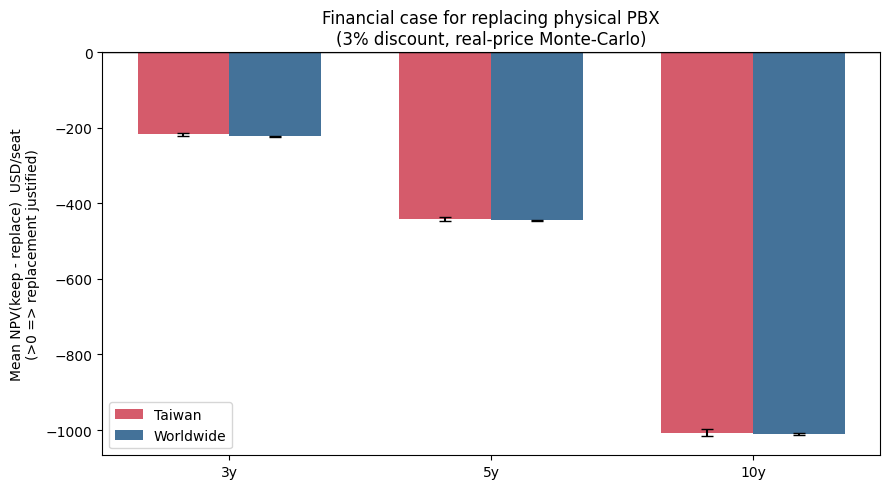

saved -> /Users/dennis_leedennis_lee/Documents/GitHub/pbx_estimation/data/processed/financial_hypothesis.png


In [6]:
# Visual summary: mean per-seat NPV saving from replacing, with 95% CI, by scope & horizon.
# Plot text is English-only by repo convention (CJK glyphs are absent from the CI fonts;
# the bilingual narrative lives in the markdown cells).
fig, ax = plt.subplots(figsize=(9, 5))
colors = {"Taiwan": "#d1495b", "Worldwide": "#30638e"}
width = 0.35
x = np.arange(len(HORIZONS))
for i, scope in enumerate(["Taiwan", "Worldwide"]):
    sub = results[results.scope == scope].set_index("horizon_years").loc[HORIZONS]
    err = [sub.mean_delta - sub.ci_low, sub.ci_high - sub.mean_delta]
    ax.bar(x + (i - 0.5) * width, sub.mean_delta, width, yerr=err, capsize=4,
           color=colors[scope], label=scope, alpha=0.9)
ax.axhline(0, color="k", lw=1)
ax.set_xticks(x); ax.set_xticklabels([f"{h}y" for h in HORIZONS])
ax.set_ylabel("Mean NPV(keep - replace)  USD/seat\n(>0 => replacement justified)")
ax.set_title("Financial case for replacing physical PBX\n(3% discount, real-price Monte-Carlo)")
ax.legend(); fig.tight_layout()
fig.savefig(PROC / "financial_hypothesis.png", dpi=120)
plt.show()
print("saved ->", PROC / "financial_hypothesis.png")

## 6. Sensitivity to the discount rate / 折現率敏感度

**EN.** Because the 3% rate is the model's key time-value lever, we re-run all tests across
**0%–8%** and check whether the decision changes. The table below shows `reject_H0` (the share of
the sweep that rejects H₀) for each scope/horizon: a value of **0 means H₀ is *not* rejected** and
**1 means it *is*** rejected. A row that is **uniform** (all 0 or all 1) means the verdict does
**not** depend on the exact discount-rate choice.

**繁中.** 由於 3% 折現率是模型的關鍵時間價值槓桿，我們在 **0%–8%** 範圍重跑所有檢定，
檢視判定是否改變。下表顯示各範圍／期間的 `reject_H0`（拒絕 H₀ 的比例）：**0 代表未拒絕 H₀**，
**1 代表拒絕 H₀**。若某列**整列一致**（全為 0 或全為 1），代表該判定**不**取決於折現率的確切選擇。

In [ ]:
sweep = []
for rate in [0.0, 0.02, 0.03, 0.05, 0.08]:
    for h in HORIZONS:
        for scope, sample in [("Taiwan", tco_delta_samples(TW, h, rate=rate)),
                              ("Worldwide", np.concatenate(
                                  [tco_delta_samples(m, h, rate=rate) for m in MARKETS]))]:
            r = run_test(sample)
            sweep.append({"rate": rate, "scope": scope, "horizon_years": h,
                          "mean_delta": r["mean_delta"], "p_value": r["p_value"],
                          "reject_H0": r["p_value"] < 0.05})
sweep = pd.DataFrame(sweep)
pivot = sweep.pivot_table(index=["scope", "horizon_years"], columns="rate",
                          values="reject_H0").astype(int)
display(pivot)

uniform = (pivot.nunique(axis=1) == 1).all()
any_reject = bool(pivot.values.any())
print(f"Every row uniform across 0%-8%? {uniform}  |  any rejection anywhere? {any_reject}")
print("Reading: all-zero rows => H0 is NOT rejected at any discount rate, i.e. the 'do not "
      "replace on cost alone' verdict is robust to the 0%-8% discount-rate assumption.")

## 7. Interpretation / 結論詮釋

### What the test actually found / 檢定的實際結果
**EN.** Under this **narrow, operating-cost-only** model, **H₀ is not rejected in any of the six
cases** (Taiwan and Worldwide, 3/5/10 years). The mean per-seat NPV difference `NPV(keep − replace)`
is **negative everywhere** and grows **more** negative as the horizon lengthens
(≈ −\$220 at 3y → ≈ −\$1,040 at 10y). In plain terms: with these real published prices, the
multi-year cloud **subscription stream costs more** in present-value than simply paying the
physical PBX's annual **maintenance**, so the data do **not** support replacement *on cost alone* —
and the gap widens over time rather than closing.

**繁中.** 在此**僅考量營運成本**的狹義模型下，**六種情境（台灣與全球，3/5/10 年）皆無法拒絕
H₀**。每席位 NPV 差額 `NPV(續用 − 汰換)` **全部為負**，且隨期間拉長而**愈來愈負**
（約 −\$220＠3 年 → 約 −\$1,040＠10 年）。白話說：在這些真實公開價格下，多年期雲端**訂閱
費用流**的現值高於僅支付實體 PBX 的年度**維護費**，故資料**不**支持*僅就成本*汰換——
且差距隨時間擴大而非縮小。

### Why every p-value is ≈ 1.000 / 為何 p 值皆約等於 1.000
**EN.** This is **not** a bug. The test is **one-sided** for H₁: mean Δ **> 0**. Because the
observed mean is strongly **negative**, the evidence points the *opposite* way to H₁, so the
one-sided p-value is ≈ 1. A small two-sided p with a negative mean would instead signal significant
evidence that replacement is *more* expensive. The large **negative Cohen's d** (≈ −0.9 to −1.6)
likewise measures how *decisively* the cost gap favours keeping, not replacing.

**繁中.** 這**並非**錯誤。本檢定對 H₁：平均 Δ **> 0** 採**單尾**。由於觀測平均值明顯為**負**，
證據方向與 H₁ *相反*，故單尾 p 值約為 1。負的 **Cohen's d**（約 −0.9 至 −1.6）同樣衡量
成本差距「決定性地」偏向續用而非汰換。

### Reconciling with the cited "cloud saves 30–40%" figures / 與「雲端省 30–40%」來源的調和
**EN.** §2 lists a vendor-reported *cloud TCO advantage of 30–40%*, which appears to **contradict**
this result. It does not, once scope is matched: those industry figures are **fully-loaded** TCO —
they count on-prem **IT labour, hardware refresh every 5–7 years, downtime, power, rack/real-estate,
and forced PSTN/EOL migration**. This model deliberately includes **only** capex-linked maintenance
plus a decline-driven stranding write-off, to isolate the *pure cash* comparison. The honest reading
is therefore: **on bare recurring cost the physical box can look cheaper, but that ignores the very
risk/labour costs that make replacement compelling in practice** — and which the EOL'd platforms in
this project's registry (Panasonic KX-TDA, Siemens HiPath, etc.) already incur.

**繁中.** §2 列出業界回報的*雲端 TCO 優勢 30–40%*，看似與本結果**矛盾**。一旦對齊範圍即不矛盾：
那些數字是**全載**TCO，計入地端的 **IT 人力、每 5–7 年硬體汰換、停機、電力、機櫃／空間、
以及被迫的 PSTN／EOL 遷移**。本模型刻意**僅**納入與資本支出連動的維護費，加上由衰退驅動的
擱淺打銷，以隔離*純現金*比較。誠實的解讀是：**僅就經常性現金成本，實體設備可能看似較便宜，
但這忽略了真正使汰換具說服力的風險／人力成本**——而本專案目錄中已 EOL 的平台
（Panasonic KX-TDA、Siemens HiPath 等）正承擔這些成本。

### Scope & limitations / 範圍與限制
**EN.** This notebook answers the **strict cash-cost** form of the question. It does **not** monetise
reliability/security risk, staff time, or the fact that a kept PBX must *eventually* migrate anyway
(only partially captured by the stranding term). A fuller "risk-adjusted" scenario that prices the
EOL/forced-migration premium would push the verdicts toward replacement; see the boxed assumptions
in §2 for the levers. The stranding term still orders markets by decline speed — consistent with
notebooks 03–08 — but on its own it is **not large enough to flip** the cost verdict.

**繁中.** 本筆記本回答的是**嚴格現金成本**版本的問題。它**未**將可靠度／資安風險、人員工時，
或「續用的 PBX 終究仍須遷移」（僅由擱淺項部分捕捉）貨幣化。若建立計入 EOL／強制遷移溢價的
「風險調整」情境，判定將偏向汰換；可調槓桿見 §2 的假設方框。擱淺項仍依衰退速度排序各市場
（與筆記本 03–08 一致），但僅憑其自身**不足以翻轉**成本判定。

## 8. Data sources / 資料來源

**EN.** Sources for the price anchors used in the TCO model (§2):

| # | Source | Used for / 用途 |
|---|---|---|
| 1 | [PBX.IM 2026 — PBX Phone System Cost](https://www.pbx.im/blog/pbx-phone-system-cost) | Physical PBX upfront capex |
| 2 | [JustCall 2026 — PBX Phone System Costs](https://justcall.io/blog/pbx-phone-system-cost.html) | Physical PBX upfront capex |
| 3 | [CloudTalk 2026 — Hosted PBX Pricing](https://www.cloudtalk.io/top-cloud-pbx/) | Cloud / IP-PBX subscription |
| 4 | [Avoxi 2025 — Hosted PBX Pricing](https://www.avoxi.com/blog/hosted-pbx-pricing/) | Cloud / IP-PBX subscription |
| 5 | [VitalPBX 2025 — On-Prem PBX Full Cost Breakdown](https://vitalpbx.com/blog/on-prem-pbx-in-2025-full-cost-breakdown-and-is-it-still-worth-it/) | Physical maintenance + line rental |
| 6 | [bluIP 2026 — Cloud vs On-Premises PBX Cost Comparison](https://www.bluip.com/blog/artificial-intelligence/cloud-pbx-vs-on-premises-pbx-comparison) | 5-yr cloud TCO advantage (cross-check) |

Decline trajectory: `data/processed/longhorizon_projection.csv` (produced by notebooks 03–08).

**繁中.** TCO 模型（§2）所用價格錨點之來源：

- **PBX.IM 2026、JustCall 2026** — 實體 PBX 前期資本支出
- **CloudTalk 2026、Avoxi 2025** — 雲端／IP-PBX 訂閱費用
- **VitalPBX 2025** — 實體維護＋線路租金
- **bluIP 2026** — 5 年雲端 TCO 優勢（交叉驗證）
- 衰退軌跡：`data/processed/longhorizon_projection.csv`（由筆記本 03–08 產生）